<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# Tarea semanal 3
#### Autor:Nicolas Trombetta
#### Profesor: Mariano Llamedo Soria

Se pide obtener un filtro chebyshev a partir de la siguiente plantilla
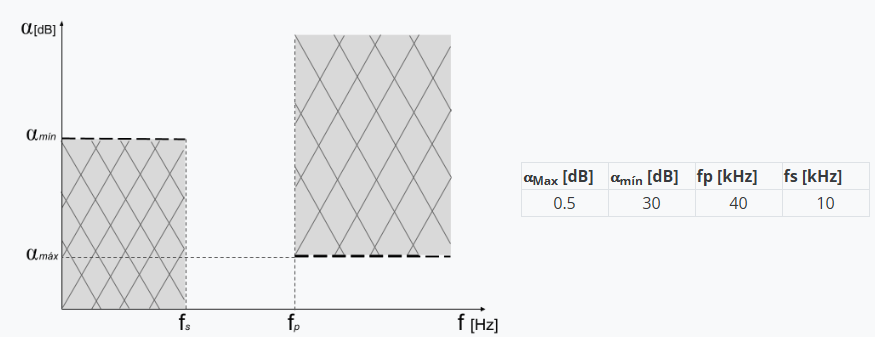

Si normalizamos la frecuencia con $\Omega_\omega=2\pi f_p$ tenemos que:
$$
f_p=1 \qquad\qquad f_s=1/4
$$

Aplicamos la transformacion $Pasa Altos\to Pasa Bajos$. Para ello reemplazamos $\Omega=\frac{1}{w}$ de forma que la nueva plantilla queda:
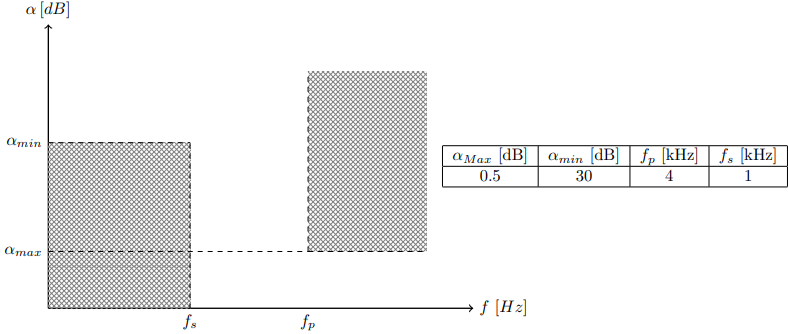

#### Aproximacion de Chevyshev
$$
|T(jw)|^2 = \frac{1}{1+\xi^2 cosh^2(n cosh^{-1}(w))} 
$$

Evaluando en $w=1$ nos queda que:
$$
|T(jw)|^2 =\frac{1}{1 + \xi^2}
$$
Ahora obligamos a que cumpla con la condicion $\alpha_{max}$ en es punto, entonces:
$$
\xi^2=10^{\frac{\alpha_{max}}{10}}-1
\xi^2=10^{\frac{0.5}{10}}-1=0.122
$$

ahora buscamos el $n$ para que cumpla con la condicion de $\alpha_{min}$, para ello evaluamos en $w=4$ y obligamos a que:
$$
\alpha_{min}=10log(1+\xi^2(cosh^2(n cosh^{-1}(4))))
$$
Para encontrar $n$ iteramos y obtenemos la siguiente tabla:
\begin{array}{c|c}
n & \alpha \\ \hline
1 & 4.70 \\
2 & 20.72 \\
3 & 38.62
\end{array}

Nos quedamos con $n=3$ porque cumple con la condicion de sobra.
Buscamos ahora el polinomio de grado 3 de chebyshev:
$$
\begin{array}{l}
C_0 = 1 \\
C_1 = w \\
C_2 = 2wC_1 - C_0 = 2w^2 - 1 \\
C_3 = 2wC_2 - C_1 = 4w^3 - 3w
\end{array}
$$

De forma que la transferencia queda:
$$
|T(jw)|^2=\frac{1}{1+\xi^2(4w^3-3w)^2}=\frac{1}{1+\xi^2(16w^6-24w^4+9w^2)}
$$
Reemplazando $w=\frac{s}{j}$:
$$
|T(s)|^2=\frac{1}{1+\xi^2(-4s^6-12s^4-9s^2)}
$$
Reescribiendo queda:
$$
|T(s)|^2=\frac{\frac{1}{16\xi^2}}{s^6+\frac{3}{2}s^4+\frac{9}{16}s^2-\frac{1}{16\xi^2}}
$$
Para poder encontrar la $T(s)$ que nos interesa plantemos que:
$$
T(s)=\frac{A}{s^3+Bs^2+cs+A} 
$$
entonces:
$$
T^*(s)=T(-s)=\frac{A}{-s^3+Bs^2-Cs+A} 
$$
$$
T^*(s)T(s)=|T(s)|^2=\frac{-A^2}{s^6+(2C-B^2)s^4+(C^2-2AB)s^2-A^2}
$$
igualando los coeficientes nos queda el siguiente sistema de ecuaciones:
$$
-A^2=-\frac{1}{16\xi^2}
2C-B^2=\frac{3}{2}
C^2-2AB=\frac{9}{16}
$$

Tras resolverla se obtiene que:
$$
T(s)=\frac{0.7157}{s^3+1.2529s^2+1.5348s+0.7157}
$$
Finalmente, aplicando la transformacion $Pasa bajos \to Pasa altos$
$$
T(s)=\frac{S^3}{s^3+2.1449s^2+1.7508s+1.3974}
$$

#### Simulacion en python

epsilon^2 = 0.12201845430196334
Orden: 3
Numerador: [1. 0. 0. 0.]
Denominador: [1.         2.14462593 1.75062714 1.3972456 ]


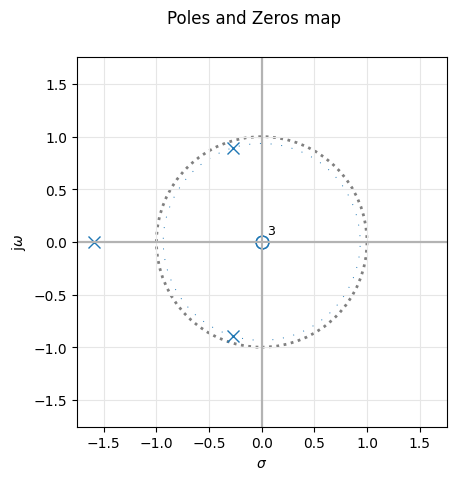

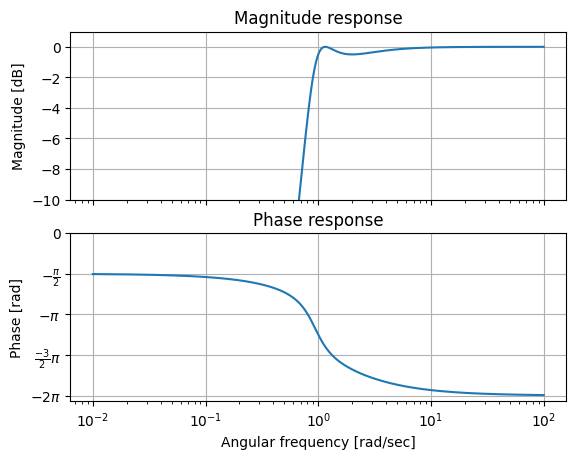

In [48]:
from scipy import signal
import matplotlib as mpl
from matplotlib import pyplot as plt
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys

eps2 = 10**(0.5/10) - 1

print("epsilon^2 =", eps2)

orden, wn = signal.cheb1ord(
    wp=1,
    ws=4,
    gpass=0.5,
    gstop=30,
    analog=True
)

P, Q = signal.cheby1(
    orden,
    0.5, 
    1,
    analog=True
)

Ph, Qh = signal.lp2hp(P, Q, wo=1);


print("Orden:", orden)
print("Numerador:", Ph)
print("Denominador:", Qh)

T=signal.TransferFunction(Ph,Qh)

pzmap(T)
_, axes_hdl = bodePlot(T)
plt.sca(axes_hdl[0])
plt.ylim([-10, 1])
plt.gca
plt.show()

#### Implementacion del circuito
Para poder implementar el filtro,reescribimos $T(s)$ de la siguiente forma:
$$
T(s)=\frac{s}{s+1.5965}\frac{s^2}{s^2+0.5484 s+0.8753}
$$

Para implemtentar la parte de primer orden con elementos pasivos, se propone usar RC con el capacitor en derivacion.
<div align="center">
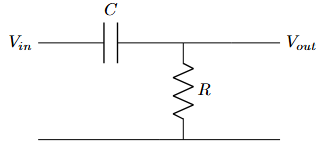
</div>


Donde 
$$
\frac{V_{out}}{V_{in}}=\frac{s}{s+\frac{1}{RC}}
$$

Entonces
$$
RC=0.6264
$$
Si tomamos $R=10k$, nos queda $C=62,64uF$
Desnormalizando estos valores por la norma de frecuencia, es decir, $\Omega_\omega=2\pi f_p=80000\pi$
Obtenemos que: 
$$
R=10k \qquad\qquad
C=250pf
$$
Y para el circuito de segundo orden, se propone la siguiente topologia:

<div align="center">
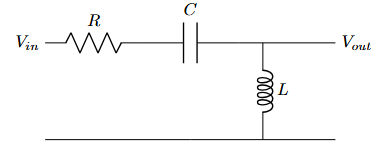
</div>


Sabemos que la transferencia que queremos lograr tiene $w_0=0.9356$ y $Q=1.706$
Entonces tomando como vimos en clases $C=\frac{1}{Q}$ y $L=Q$ nos queda que
$$
C=0.5861 \qquad\qquad
L=1.706
$$
Desnormalizando para obtener $w_0=0.9356$:
$$
C=0.6264 \qquad\qquad
L=1.8234
$$
Y desnormalizando nuevamente pero para obtener $w_0=80000\pi$ y $R=10k$
$$
C=250pf \qquad\qquad
L=0.725mHy
$$


#### Simulacion en LTSpice
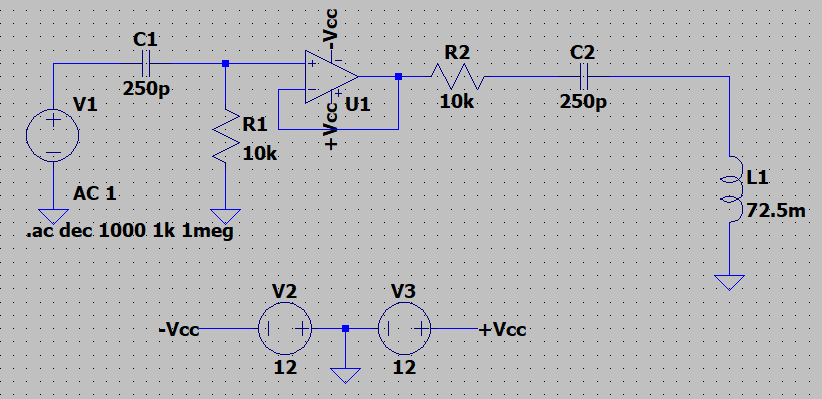

La transferencia que se obtiene:

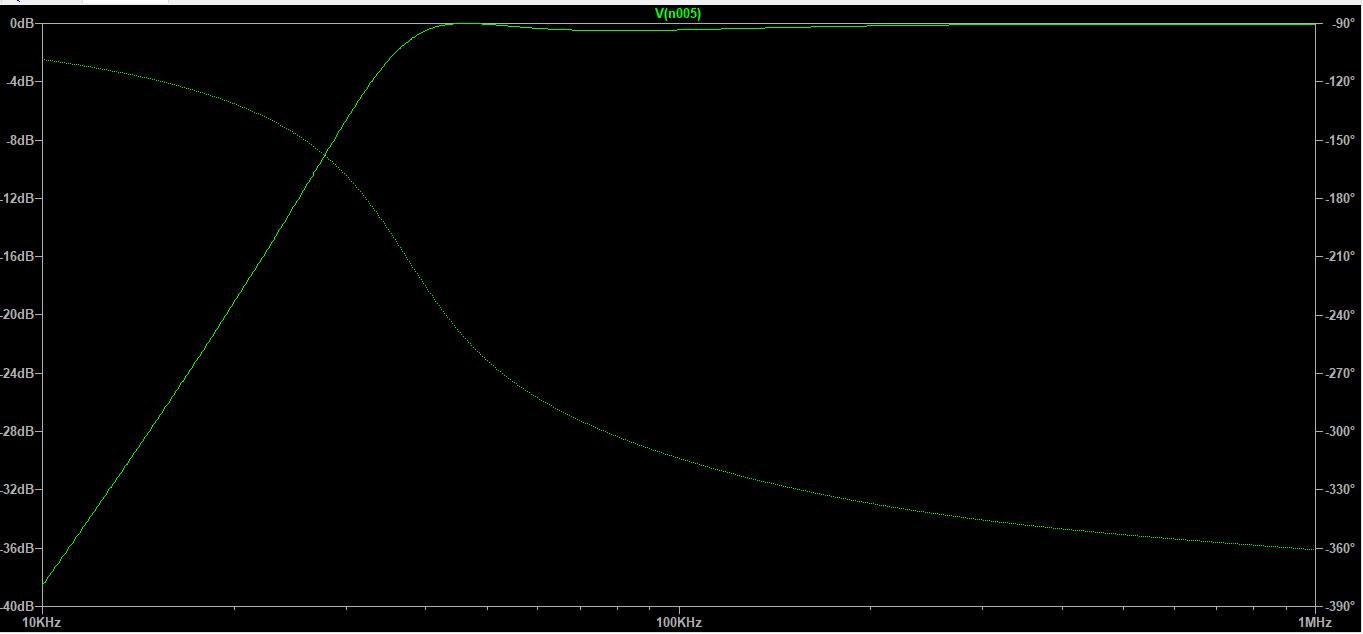

Analizamos Algunos puntos de la grafica, para verificar que cumple con la plantilla:


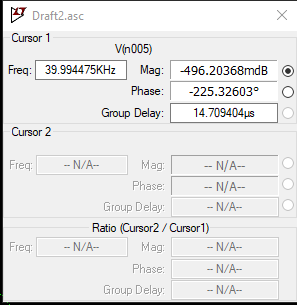

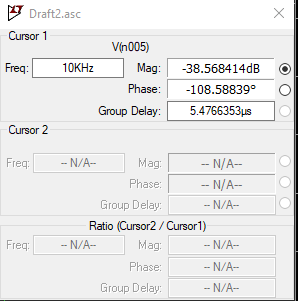


Ahora queremos emular el comportamiento del inductor con un GIC de Antoniuv,para ello recordamos como es la expresion:
$$
Z_{eq}=\frac{Z_1Z_3Z_5}{Z_2Z_4}
$$

Si, por ejemplo, Z_4 es un capacitor y todo las demas impedancias son resistencias, obtenemos:
$$
Z_{eq}=S\frac{CR_1R_3R_5}{R_2}
$$
si igualamos esto a la impedancia de un inductor podemos determinar que:
$$
L_{eq}=\frac{CR_1R_3R_5}{R_2}
$$

Si tomamos  $R_1=R_2=R_3=R_5=10k$, tenemos que $C=725pF$.
Simulamos el circuito:

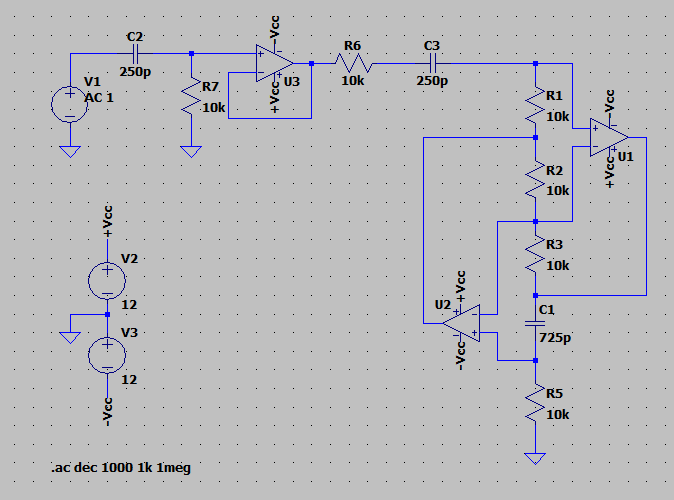

y volvemos a mirar los puntos que nos interesan:

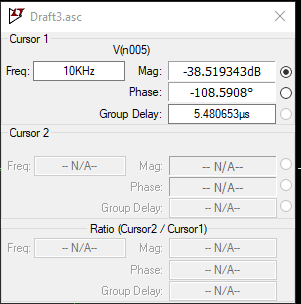

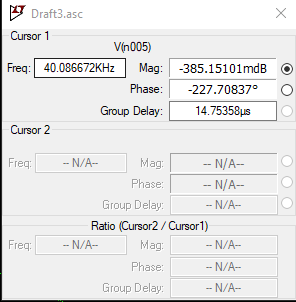

#### Multiple feedback

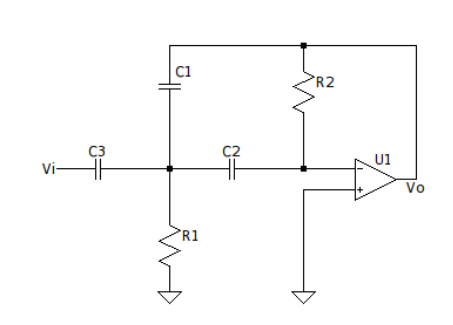

La trasferencia de este circuito es:
$$
T(s)=-\frac{C_3}{C_1}\frac{s^2}{s^2+s\frac{G_2(C_1+C_2+C_3)}{C_2C_1}+\frac{G_1G_2}{C_1C_2}}
$$
$$
\omega_0 ^2 =\frac{G_1G_2}{C_1C_2}
$$
$$
\frac{\omega_0}{Q}=\frac{G_2(C_1+C_2+C_3)}{C_2C_1}
$$
si normalizamos con $\Omega_z=C_1$ y $\Omega_\omega=w_0$ y tomamos $C_1=C_2=C_3$
entonces:
$$
R_1=1/3Q
$$
$$
R_2=3Q
$$

Sustituyendo por $Q=1.706$

$$
C_1=C_2=C_3=1
$$

Desnormalizando para $w_0=0.9356$
$$
\begin{array}{l}
C_1=C_2=C_3=1.0688 \\
R_2=5.118 \\
R_1=0.1953
\end{array}
$$

Desnormalizando nuevamente para $\Omega_\omega=80000\pi$ y $C_1=100pF$

$$
\begin{array}{l}
C_1=C_2=C_3=100\,\text{pF} \\
R_2=217.5\,\text{k}\Omega \\
R_1=8.3\,\text{k}\Omega
\end{array}
$$

### Simulacion en LTspice
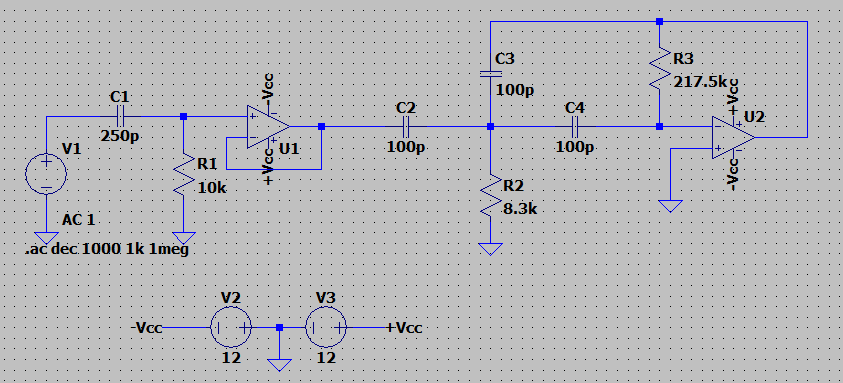

La trasferencia queda:
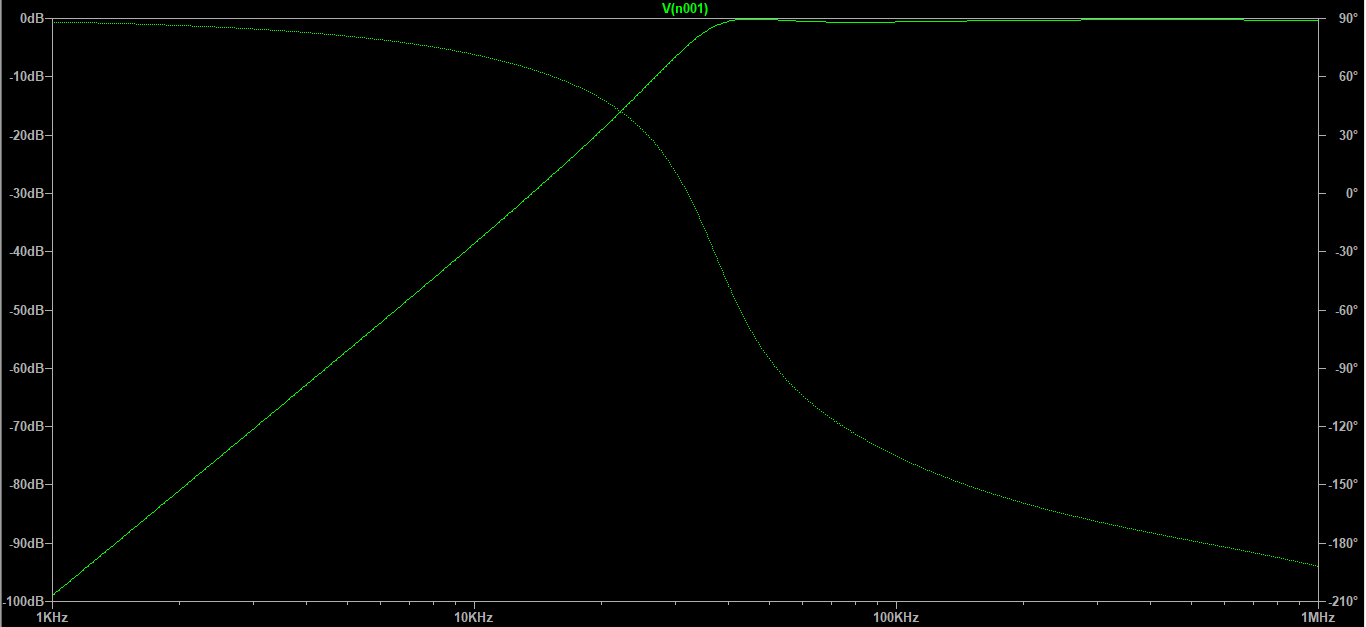

### Analisis de sensibilidad

Analizemos primero:$S^{C_1}_{w_0}$
$$
S^{C_1}_{w_0}=\frac{w_0}{C_1}\frac{\partial C_1}{\partial w_0}
$$

Reemplazando $C_1=\frac{G_1G_2}{{\omega_0}^2 C_2}$ 
$$
S^{C_1}_{w_0}=\frac{w0}{\frac{G_1G_2}{{\omega_0}^2 C_2}}\frac{\partial(\frac{G_1G_2}{{\omega_0}^2 C_2}$)}{\partial w_0}
$$
$$
S^{C_1}_{w_0}=-2
$$

Analizemos ahora:$S^{R_1}_{Q}$
$$
S^{R_1}_{Q}=\frac{Q}{R_1}\frac{\partial R_1}{\partial Q}
$$
Como R_1 no depende de Q entonces:$\frac{\partial R_1}{\partial Q}=0$ y:
$$
S^{R_1}_{Q}=0
$$

Analizemos finalmente:$S^{R_2}_{Q}$
$$
S^{R_2}_{Q}=\frac{Q}{R_2}\frac{\partial R_2}{\partial Q}
$$
Reemplazando $Q=\frac{w_0C_2C_1R_2}{C_1+C_2+C_3}$
$$
S^{R_2}_{Q}=\frac{w_0C_2C_1}{C_1+C_2+C_3}\frac{C_1+C_2+C_3}{w_0C_2C_1}=1
$$

### Maxima planicidad
Nos interesa ver si la aproximacion de maxima planicidad logra, con el mismo orden, cumplir con la plantilla.
Sabiendo que $\xi^2=0.122$,calculamos n iterando:
$$
\alpha_{min}=10log(1+\xi^2 4^{2n})
$$

\begin{array}{c|c}
n & \alpha \\ \hline
1 & 4.70 \\
2 & 15.08 \\
3 & 27 \\
4 & 39.02
\end{array}

Como podemos ver para que tenga maxima planicidad deberia tener un orden mas que cheby.



### Conclusión

En este trabajo se diseñó e implementó un filtro pasa altos de orden 3 con aproximación 
de Chebyshev a partir de una plantilla de especificaciones dada.

En primer lugar, se realizó la aproximación matemática, determinando los parámetros 
ξ² = 0.122 y n = 3, obteniendo la función de transferencia normalizada y luego aplicando 
la transformación pasa bajos → pasa altos. Se verificó que la aproximación de Chebyshev 
cumple con las condiciones de plantilla con n = 3, mientras que la aproximación de máxima 
planicidad (Butterworth) requeriría un orden mayor (n = 4) para satisfacer las mismas 
especificaciones.

El filtro se descompuso en una etapa de primer orden (RC pasivo) y una de segundo orden, 
implementada de tres formas distintas:

- **RLC pasivo:** usando un inductor y un capacitor, con la simulación en LTSpice 
verificando el cumplimiento de la plantilla en los puntos de interés.

- **GIC de Antoniou:** permite emular el inductor activamente usando resistencias, 
capacitores y amplificadores operacionales, eliminando el componente inductivo físico 
y sus limitaciones prácticas. Los resultados de simulación coincidieron con los del 
circuito RLC original.

- **Multiple Feedback (MFB):** topología activa con realimentación múltiple.